## Donut Chart Template

In [1]:
# ------------------------------------------------------------------------
# Donut Chart Template
#
# Standard chart styling:
# - Figure size: 8 x 8
# - Donut width: 0.72
# - Start angle: 90
# - Slice borders: white
# - Percentage labels: show only above threshold
# - Layout: simple title with legend aligned to the right
#
# Default color palette:
# - "#4e79a7"
# - "#59a14f"
# - "#f28e2b"
# - "#e15759"
# - "#76b7b2"
# - "#edc948"
# - "#b07aa1"
# - "#ff9da7"
#
# Capital structure color scheme:
# - Equity: "#90caf9"
# - Debt: "#ef5350"
# - Cash: "#2e7d32"
#
# Oil & gas color scheme:
# - Natural Gas: "#1f4e79"
# - Condensate: "#f39c12"
# - Light Crude Oil: "#2b2b2b"
# - Heavy Crude: "#5c3a21"
# - LNG: "#4a90e2"
# - NGLs: "#16a085"
#
# Commodity color scheme:
# Use an intuitive fallback color if a relevant commodity is not listed.
# - Gold: "#d4af37"
# - Silver: "#ececec"
# - Copper: "#b87333"
# - Zinc: "#7f7f7f"
# - Lead: "#4f4f4f"
# - Nickel: "#7f8c8d"
# - Iron: "#8b0000"
# - Cobalt: "#0047ab"
# - Lithium: "#ff3366"
# - Phosphate: "#ffcc00"
# ------------------------------------------------------------------------


## Chart 1: Company Name - Capital Structure

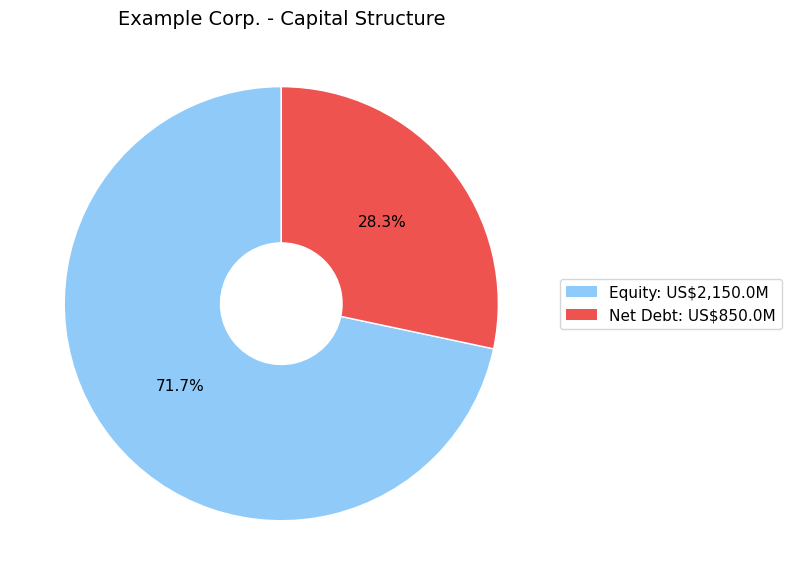

In [2]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------------------
# Purpose:
# Build a "Capital Structure" donut chart showing how the company's
# capitalization is split between equity and net debt, or equity and net
# cash when cash exceeds debt.
#
# Selection guidance for the LLM:
# - Use this chart when the company has enough disclosed balance sheet and
#   market data to calculate a clean capital structure snapshot.
# - Market capitalization should reflect the company's equity value.
# - Total debt and cash should come from company-reported financial
#   statements or other credible official disclosures.
# - Inputs should be taken from a consistent period or date so the chart
#   reflects a coherent capital structure view.
#
# Expected output title pattern:
#   "{company_name} - Capital Structure"
# ------------------------------------------------------------------------

# Example company metadata chosen by the upstream LLM / caller.
company_name = "Example Corp."

# Capital structure inputs in US$ millions.
market_cap = 2_150.0
total_debt = 1_080.0
cash = 230.0

# Helper functions
def pct_only(threshold=5):
    """
    Return a formatter for pie-chart percentage labels.

    Only show percentage labels for slices at or above the threshold to
    keep the chart readable.
    """
    def _fmt(pct):
        return f"{pct:.1f}%" if pct >= threshold else ""
    return _fmt


def _legend_handles(colors):
    """
    Build simple colored square legend handles matching the pie slices.
    """
    return [Patch(facecolor=c) for c in colors]


def _safe_show(values, chart_name):
    """
    Guardrail: do not render charts when all values are missing, zero,
    or otherwise non-meaningful.
    """
    if not values or sum(v for v in values if v is not None) <= 0:
        raise ValueError(f"{chart_name}: all values are zero or missing.")


def plot_capital_structure(
    company_name,
    market_cap,
    total_debt,
    cash,
    currency="US$",
    equity_color="#90caf9",
    debt_color="#ef5350",
    cash_color="#2e7d32",
):
    """
    Render a donut chart showing capital structure.

    The chart compares:
    - Equity and Net Debt, if debt exceeds cash
    - Equity and Net Cash, if cash exceeds debt

    Expected inputs are in millions.

    Usage rules for the upstream LLM:
    - Confirm market cap, debt, and cash are available from credible
      sources.
    - Use inputs from a consistent date or reporting period.
    - Avoid using this chart when capital structure inputs are incomplete,
      stale, or not directly supported by company disclosure.
    """
    net_debt = total_debt - cash

    if net_debt >= 0:
        vals = [market_cap, net_debt]
        colors = [equity_color, debt_color]
        legend_labels = [
            f"Equity: {currency}{market_cap:,.1f}M",
            f"Net Debt: {currency}{net_debt:,.1f}M",
        ]
    else:
        net_cash = abs(net_debt)
        vals = [market_cap, net_cash]
        colors = [equity_color, cash_color]
        legend_labels = [
            f"Equity: {currency}{market_cap:,.1f}M",
            f"Net Cash: {currency}{net_cash:,.1f}M",
        ]

    _safe_show(vals, "Capital Structure")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        vals,
        labels=None,
        autopct=pct_only(5),
        startangle=90,
        colors=colors,
        wedgeprops=dict(width=0.72, edgecolor="white"),
        textprops={"fontsize": 11},
    )

    ax.set_title(f"{company_name} - Capital Structure", fontsize=14)
    ax.legend(
        _legend_handles(colors),
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


# Plot the chart after the upstream LLM / caller has:
# 1. verified market cap, debt, and cash from reliable disclosure,
# 2. aligned the inputs to a consistent reporting date,
# 3. confirmed the company should be shown as Equity + Net Debt or
#    Equity + Net Cash based on the calculation.
plot_capital_structure(
    company_name=company_name,
    market_cap=market_cap,
    total_debt=total_debt,
    cash=cash,
    currency="US$",
)

## CHART 2: Company Name - NAV vs Enterprise Value

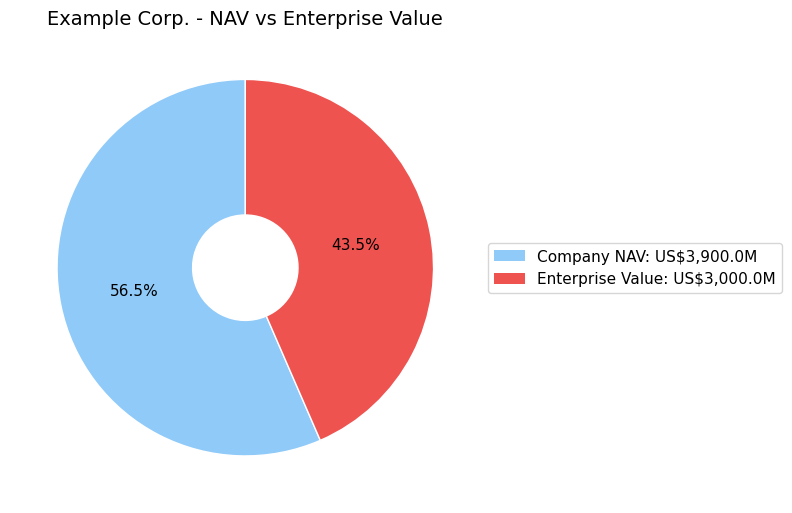

In [3]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------------------------------------------------------------------
# Purpose:
# Build a "NAV / NPV vs Enterprise Value" donut chart using only
# company-disclosed NAV or study-level NPV data. The upstream LLM should
# decide whether this chart is appropriate for the company being analyzed,
# determine whether the disclosed valuation metric is best described as
# NAV or NPV, and then supply the correct label.
#
# Expected output title pattern:
#   "{company_name} - NAV vs Enterprise Value"
#
# This chart should not be used if NAV / NPV is speculative, inferred, stale
# relative to the company structure, or unavailable from credible official
# disclosure.
# ---------------------------------------------------------------------------

# Example company name.
company_name = "Example Corp."

# Enterprise Value inputs in US$ millions.
market_cap = 2_150.0
total_debt = 1_080.0
cash = 230.0

# Standard EV calculation:
enterprise_value = market_cap + total_debt - cash  # US$M

# Disclosed valuation figure in US$ millions.
nav_or_npv = 3_900.0

# nav_label should reflect the nature of the disclosed valuation:
# - "Company NAV" for a corporate NAV
# - "Asset NAV" for an asset-level NAV
# - "Project NPV" or similar for study-based NPV
# The upstream LLM should choose the most accurate label based on source.
nav_label = "Company NAV"


def pct_only(threshold=5):
    """
    Return a formatter for pie-chart percentage labels.

    Only show percentage labels for slices at or above the threshold to
    keep the chart readable.
    """
    def _fmt(pct):
        return f"{pct:.1f}%" if pct >= threshold else ""
    return _fmt


def _legend_handles(colors):
    """
    Build simple colored square legend handles matching the pie slices.
    """
    return [Patch(facecolor=c) for c in colors]


def _safe_show(values, chart_name):
    """
    Guardrail: do not render charts when all values are missing, zero,
    or otherwise non-meaningful.
    """
    if not values or sum(v for v in values if v is not None) <= 0:
        raise ValueError(f"{chart_name}: all values are zero or missing.")


def plot_nav_vs_ev(
    company_name,
    nav_or_npv,
    enterprise_value,
    nav_label="NAV",
    currency="US$",
    nav_color="#90caf9",
    ev_color="#ef5350",
):
    """
    Render a donut chart comparing disclosed NAV / NPV against
    Enterprise Value.

    Expected inputs are in millions.

    Usage rules for the upstream LLM:
    - Confirm the NAV / NPV figure exists in a credible official source.
    - Choose the correct nav_label based on the disclosed metric.
    - Ensure EV is calculated from a compatible reporting date.
    - Avoid using this chart when the valuation figure is inferred,
      estimated, outdated, or unsupported by disclosure.
    """
    vals = [nav_or_npv, enterprise_value]
    colors = [nav_color, ev_color]

    _safe_show(vals, "NAV vs Enterprise Value")

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        vals,
        labels=None,
        autopct=pct_only(7),
        startangle=90,
        colors=colors,
        wedgeprops=dict(width=0.72, edgecolor="white"),
        textprops={"fontsize": 11},
    )

    ax.set_title(f"{company_name} - NAV vs Enterprise Value", fontsize=14)
    legend_labels = [
        f"{nav_label}: {currency}{nav_or_npv:,.1f}M",
        f"Enterprise Value: {currency}{enterprise_value:,.1f}M",
    ]
    ax.legend(
        _legend_handles(colors),
        legend_labels,
        bbox_to_anchor=(1.0, 0.5),
        loc="center left",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()



# Plot the chart after the upstream LLM / caller has:
# 1. verified that a credible company-disclosed NAV or study NPV exists,
# 2. selected the correct NAV / NPV label,
# 3. calculated Enterprise Value from consistent-period inputs.
plot_nav_vs_ev(
    company_name=company_name,
    nav_or_npv=nav_or_npv,
    enterprise_value=enterprise_value,
    nav_label=nav_label,
    currency="US$",
)

## CHART 3: Company Name - Revenue By Segment / Mine / Basin

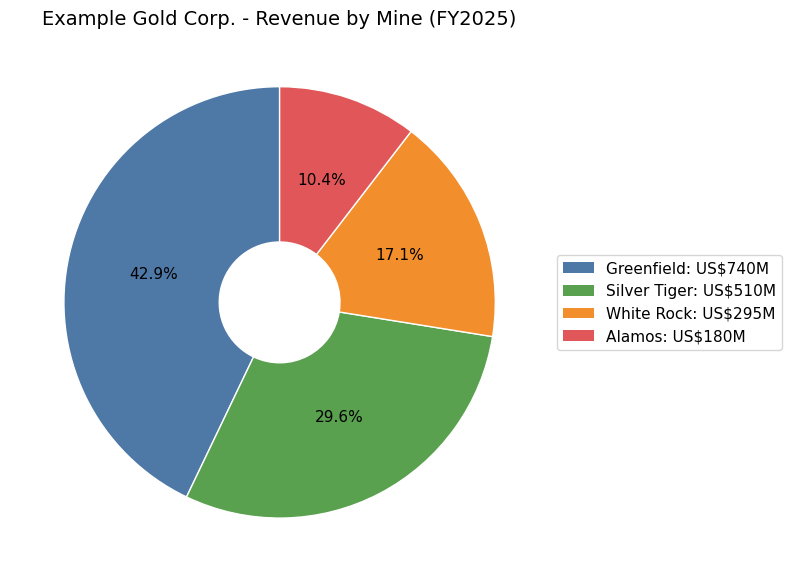

In [4]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------------------------
# Purpose:
# Build a "Revenue by ..." donut chart using officially disclosed revenue data.
# The caller/LLM should decide whether this chart is appropriate for the company 
# being analyzed, then choose the label that best matches the business structure.
#
# Label-selection guidance for the LLM:
# - Use "Mine" for a multi-asset mining company when revenue is disclosed
#   at the mine level.
# - Use "Basin" for a multi-basin oil & gas company when revenue is
#   disclosed by basin.
# - Use "Asset" when the company reports revenue by named assets/fields/
#   projects rather than by corporate segments.
# - Use "Segment" as the default when the company reports revenue by
#   operating/business segments and no more specific asset-level breakdown
#   is the primary disclosed view.
#
# Expected output title pattern:
#   "{company_name} - Revenue by {category_label} ({period_label})"
# ------------------------------------------------------------------------------

# Example company.
company_name = "Example Gold Corp."

# category_label must be selected based on the company's business structure (Mine, Basin, Asset, Segment).
category_label = "Mine"

# Choose most recent reported fiscal period when revenue breakdown is available.
period_label = "FY2025" 

# Example disclosed revenue breakdown in US$ millions.
# Despite the variable name, the keys can represent mines, segments, assets, or basins depending on category_label.
revenue_by_segment = {
    "Greenfield": 740,
    "Silver Tiger": 510,
    "White Rock": 295,
    "Alamos": 180}


# Helper functions
def pct_only(threshold=5):
    """
    Return a formatter for pie-chart percentage labels.

    Only show percentage labels for slices at or above the threshold.
    This keeps the chart readable when there are many small categories.
    """
    def _fmt(pct):
        return f"{pct:.1f}%" if pct >= threshold else ""
    return _fmt


def _legend_handles(colors):
    """
    Build simple colored square legend handles matching the pie slices.
    """
    return [Patch(facecolor=c) for c in colors]


def _safe_show(values, chart_name):
    """
    Guardrail: do not render charts when all values are missing, zero,
    or otherwise non-meaningful.

    This prevents producing a visually valid chart from invalid data.
    """
    if not values or sum(v for v in values if v is not None) <= 0:
        raise ValueError(f"{chart_name}: all values are zero or missing.")


def plot_revenue_by_segment(
    company_name,
    period_label,
    revenue_by_segment,
    currency="US$",
    colors=None,
):
    """
    Render a donut chart for officially disclosed revenue categories.
    Use only when official filings disclose category-level revenue.
    Inputs should be a dict: {category_name: revenue_in_millions}
    """
    if not revenue_by_segment:
        raise ValueError("Revenue by segment chart requires a non-empty revenue_by_segment dict.")

    labels = list(revenue_by_segment.keys())
    values = list(revenue_by_segment.values())

    _safe_show(values, "Revenue by Segment")

    if colors is None:
        default_palette = [
            "#4e79a7", "#59a14f", "#f28e2b", "#e15759",
            "#76b7b2", "#edc948", "#b07aa1", "#ff9da7",
        ]
        colors = default_palette[: len(values)]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.pie(
        values,
        labels=None,
        colors=colors,
        startangle=90,
        autopct=pct_only(5),
        wedgeprops=dict(width=0.72, edgecolor="white"),
        textprops={"fontsize": 11},
    )

    ax.set_title(f"{company_name} - Revenue by {category_label} ({period_label})", fontsize=14)
    legend_labels = [
        f"{name}: {currency}{value:,.0f}M" for name, value in revenue_by_segment.items()
    ]
    ax.legend(
        _legend_handles(colors),
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()


# Plot the chart after the upstream LLM / caller has:
# 1. verified the company discloses this revenue breakdown officially,
# 2. selected the correct category label,
# 3. supplied the latest reported period.
plot_revenue_by_segment(
    company_name=company_name,
    period_label=period_label,
    revenue_by_segment=revenue_by_segment,
    currency="US$",
)

## Chart 4: Company Name - Reserves by Asset

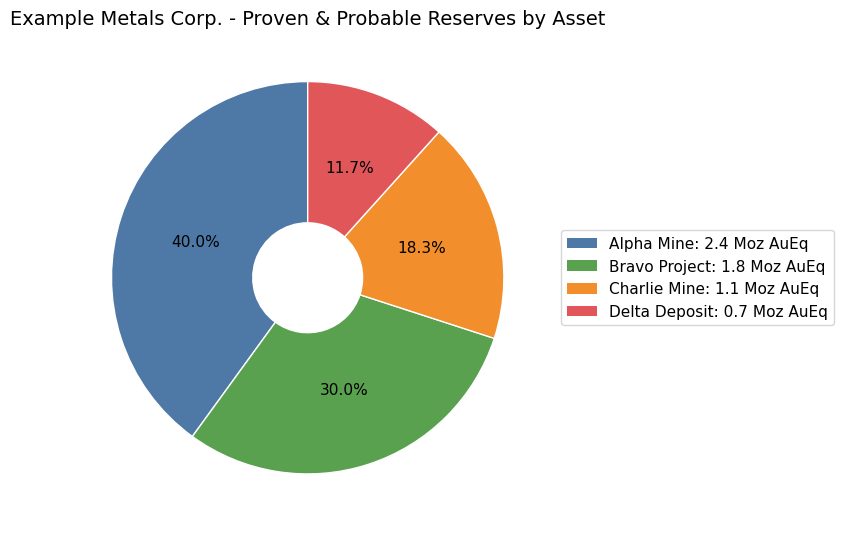

In [5]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------------------
# Purpose:
# Build a "Reserves by Asset" donut chart using only
# company-disclosed reserve data. The upstream LLM should decide whether
# this chart is appropriate for the company being analyzed, confirm that
# reserves are officially disclosed at the asset level, and supply the
# correct unit label.
#
# Selection guidance for the LLM:
# - Use this chart only when the company explicitly discloses reserve
#   balances by asset, mine, project, deposit, or similar operating unit.
# - Prefer Proven & Probable reserves (or the directly disclosed reserve
#   category) from official company filings, technical reports, annual
#   reports, or reserve statements. Inferred reserves are acceptable data
#   inputs only if P&P data is unavailable.
# - Preserve the company-reported asset names exactly as disclosed so the
#   legend and chart align with source terminology.
# - If the company reports reserves in a different unit or commodity basis,
#   update reserve_unit accordingly (for example "Moz Au", "MMbbl", "Mt",
#   or "Bcfe").
#
# Color guidance:
# - This chart uses the same default_palette as the revenue-by-segment
#   chart so categories can stay visually consistent across charts when
#   the same asset / segment names appear.
#
# Expected output title pattern:
#   "{company_name} - Reserves by Asset"
#
# This chart should not be used if reserves are not officially disclosed,
# if values are inferred, or if the company only reports total reserves
# without an asset-level breakdown.
# ------------------------------------------------------------------------


# Example company name.
company_name = "Example Metals Corp."

# Example company-disclosed reserve breakdown.
# Keys should be the exact asset / mine / project names used by the
# company. Values are expected to be numeric reserve amounts.
pp_reserves_by_asset = {
    "Alpha Mine": 2.4,
    "Bravo Project": 1.8,
    "Charlie Mine": 1.1,
    "Delta Deposit": 0.7,
}

# Unit label for the disclosed reserve values.
# Update this to match the company's reported reserve basis.
reserve_unit = "Moz AuEq"


# Helper functions
def pct_only(threshold=5):
    """
    Return a formatter for pie-chart percentage labels.

    Only show percentage labels for slices at or above the threshold to
    keep the chart readable.
    """
    def _fmt(pct):
        return f"{pct:.1f}%" if pct >= threshold else ""
    return _fmt


def _legend_handles(colors):
    """
    Build simple colored square legend handles matching the pie slices.
    """
    return [Patch(facecolor=c) for c in colors]


def _safe_show(values, chart_name):
    """
    Guardrail: do not render charts when all values are missing, zero,
    or otherwise non-meaningful.
    """
    if not values or sum(v for v in values if v is not None) <= 0:
        raise ValueError(f"{chart_name}: all values are zero or missing.")


def plot_pp_reserves_by_asset(
    company_name,
    pp_reserves_by_asset,
    reserve_unit="Moz AuEq",
    colors=None,
):
    """
    Render a donut chart for Reserves by asset.

    Expected input:
        {asset_name: reserve_amount}

    Example:
        {"Alpha Mine": 2.4, "Bravo Project": 1.8}

    Usage rules for the upstream LLM:
    - Confirm the company officially discloses asset-level reserve data.
    - Preserve asset names exactly as reported.
    - Use the correct reserve_unit based on the company's disclosure.
    - Avoid using this chart when only total company reserves are
      available and no asset-level breakdown is disclosed.
    """
    if not pp_reserves_by_asset:
        raise ValueError(
            "P&P reserves by asset chart requires a non-empty pp_reserves_by_asset dict."
        )

    # Preserve disclosed asset names exactly as reported so the chart
    # matches source terminology.
    labels = list(pp_reserves_by_asset.keys())
    values = list(pp_reserves_by_asset.values())

    # Ensure the chart is only shown when the data is meaningful.
    _safe_show(values, "Proven & Probable Reserves by Asset")

    # Use the same default qualitative palette as the revenue chart so
    # assets / segments can remain visually consistent across outputs.
    if colors is None:
        default_palette = [
            "#4e79a7", "#59a14f", "#f28e2b", "#e15759",
            "#76b7b2", "#edc948", "#b07aa1", "#ff9da7",
        ]
        colors = default_palette[: len(values)]

    fig, ax = plt.subplots(figsize=(8, 8))

    # Donut chart:
    # - labels are omitted on the wedges to reduce clutter
    # - legend carries the asset names and absolute reserve values
    # - percentages are shown only for slices above the threshold
    ax.pie(
        values,
        labels=None,
        colors=colors,
        startangle=90,
        autopct=pct_only(5),
        wedgeprops=dict(width=0.72, edgecolor="white"),
        textprops={"fontsize": 11},
    )

    ax.set_title(
        f"{company_name} - Proven & Probable Reserves by Asset",
        fontsize=14,
    )

    # Legend format shows both the disclosed asset name and the absolute
    # reserve amount using the selected unit label.
    legend_labels = [
        f"{name}: {value:.1f} {reserve_unit}"
        for name, value in pp_reserves_by_asset.items()
    ]
    ax.legend(
        _legend_handles(colors),
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# Plot the chart after the upstream LLM / caller has:
# 1. verified that asset-level reserve data is officially disclosed,
# 2. preserved the company-reported asset names,
# 3. selected the correct reserve unit from the source disclosure.
plot_pp_reserves_by_asset(
    company_name=company_name,
    pp_reserves_by_asset=pp_reserves_by_asset,
    reserve_unit=reserve_unit,
)


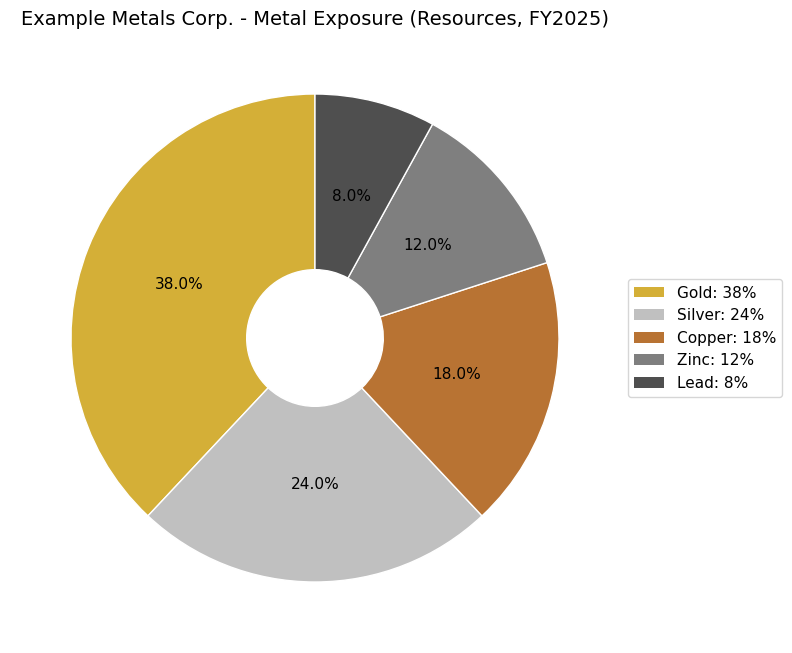

In [6]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ------------------------------------------------------------------------
# Purpose:
# Build a "Metal Exposure" donut chart showing how a company's resource or
# reserve value is distributed across commodities. The upstream LLM should
# decide whether this chart is appropriate for the company being analyzed,
# confirm that a commodity exposure breakdown can be supported by official
# disclosure or a defensible stated methodology, and use the correct period
# and basis label in the title.
#
# Selection guidance for the LLM:
# - Use this chart for polymetallic or multi-commodity companies where
#   commodity exposure is a meaningful part of the investment narrative.
# - The exposure basis should be clearly defined, such as:
#   - resources
#   - reserves
#   - production
#   - revenue
#   - in-situ value share
# - Prefer official company disclosure when available.
# - If exposure is derived rather than explicitly disclosed, the methodology
#   must be consistent, transparent, and appropriate for the chart context.
# - Preserve the commodity names exactly as used in the chosen dataset.
#
# Color guidance:
# - Keep the existing metals color scheme so the same commodity always uses
#   the same color across charts.
# - If a commodity is not in the predefined mapping, fall back to a neutral
#   default color unless a specific color convention is required.
#
# Expected output title pattern:
#   "{company_name} - Metal Exposure ({exposure_basis}, {period_label})"
#
# This chart should not be used if commodity exposure cannot be supported by
# credible disclosure or a clear, consistent calculation method.
# ------------------------------------------------------------------------


# Example company metadata chosen by the upstream LLM / caller.
company_name = "Example Metals Corp."
period_label = "FY2025"

# Basis label describing what the exposure percentages represent.
# Examples: "Resources", "Reserves", "Production", "Revenue"
exposure_basis = "Resources"

# Example polymetallic exposure breakdown expressed as percentages.
# Values should represent the share of the chosen exposure basis by metal.
metal_exposure = {
    "Gold": 38,
    "Silver": 24,
    "Copper": 18,
    "Zinc": 12,
    "Lead": 8,
}

# Keep the commodity-specific color scheme consistent across charts.
metal_colors = {
    "Gold": "#d4af37",
    "Silver": "#c0c0c0",
    "Copper": "#b87333",
    "Zinc": "#7f7f7f",
    "Lead": "#4f4f4f",
}


# Helper functions
def pct_only(threshold=5):
    """
    Return a formatter for pie-chart percentage labels.

    Only show percentage labels for slices at or above the threshold to
    keep the chart readable.
    """
    def _fmt(pct):
        return f"{pct:.1f}%" if pct >= threshold else ""
    return _fmt


def _legend_handles(colors):
    """
    Build simple colored square legend handles matching the pie slices.
    """
    return [Patch(facecolor=c) for c in colors]


def _safe_show(values, chart_name):
    """
    Guardrail: do not render charts when all values are missing, zero,
    or otherwise non-meaningful.
    """
    if not values or sum(v for v in values if v is not None) <= 0:
        raise ValueError(f"{chart_name}: all values are zero or missing.")


def plot_metal_exposure(
    company_name,
    period_label,
    metal_exposure,
    exposure_basis="Resources",
    metal_colors=None,
    default_color="#9e9e9e",
):
    """
    Render a donut chart for commodity exposure.

    Expected input:
        {metal_name: exposure_percentage}

    Example:
        {"Gold": 38, "Silver": 24, "Copper": 18}

    Usage rules for the upstream LLM:
    - Confirm the exposure basis is appropriate for the company.
    - Prefer official company disclosure when available.
    - If derived, ensure the methodology is clear and consistent.
    - Preserve commodity names exactly as used in the selected dataset.
    """
    if not metal_exposure:
        raise ValueError(
            "Metal exposure chart requires a non-empty metal_exposure dict."
        )

    # Preserve commodity names exactly as provided so the chart legend
    # matches the selected dataset.
    labels = list(metal_exposure.keys())
    values = list(metal_exposure.values())

    # Ensure the chart is only shown when the data is meaningful.
    _safe_show(values, "Metal Exposure")

    # Keep the established metals color scheme. If a metal is not present
    # in the mapping, use a neutral fallback color.
    if metal_colors is None:
        metal_colors = {
            "Gold": "#d4af37",
            "Silver": "#c0c0c0",
            "Copper": "#b87333",
            "Zinc": "#7f7f7f",
            "Lead": "#4f4f4f",
        }
    colors = [metal_colors.get(metal, default_color) for metal in labels]

    fig, ax = plt.subplots(figsize=(8, 8))

    # Donut chart:
    # - labels are omitted on the wedges to reduce clutter
    # - legend carries the commodity names and percentage shares
    # - percentages are shown only for slices above the threshold
    ax.pie(
        values,
        labels=None,
        colors=colors,
        startangle=90,
        autopct=pct_only(5),
        wedgeprops=dict(width=0.72, edgecolor="white"),
        textprops={"fontsize": 11},
    )

    ax.set_title(
        f"{company_name} - Metal Exposure ({exposure_basis}, {period_label})",
        fontsize=14,
    )

    # Legend format shows both the commodity name and its percentage share
    # of the selected exposure basis.
    legend_labels = [
        f"{metal}: {share:.0f}%"
        for metal, share in metal_exposure.items()
    ]
    ax.legend(
        _legend_handles(colors),
        legend_labels,
        loc="center left",
        bbox_to_anchor=(1.0, 0.5),
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# Plot the chart after the upstream LLM / caller has:
# 1. verified that the commodity exposure basis is appropriate,
# 2. confirmed the percentages are supported by disclosure or a consistent
#    methodology,
# 3. preserved the intended metal names and color mapping.
plot_metal_exposure(
    company_name=company_name,
    period_label=period_label,
    metal_exposure=metal_exposure,
    exposure_basis=exposure_basis,
    metal_colors=metal_colors,
)
